In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Disease Prediction Project Started!")

Disease Prediction Project Started!


In [12]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart (1).csv


In [13]:
import pandas as pd

df = pd.read_csv("heart.csv")

print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   67    1   3       116   227    0        1      128      0      0.6      0   
1   57    1   3       141   303    0        2      153      0      3.2      0   
2   43    0   2       108   191    0        2      151      0      1.0      0   
3   71    1   1       165   276    0        0      130      1      1.7      2   
4   36    1   0       153   275    0        1      169      0      1.2      2   

   ca  thal  target  
0   0     2       1  
1   0     1       1  
2   1     1       0  
3   0     1       1  
4   0     2       0  


In [14]:
print(df.shape)
print(df.columns)
print(df.isnull().sum())

(300, 14)
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


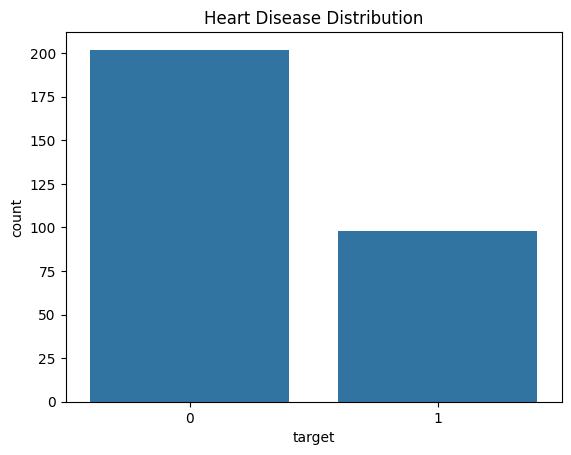

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()

In [16]:
X = df.drop("target", axis=1)
y = df["target"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   67    1   3       116   227    0        1      128      0      0.6      0   
1   57    1   3       141   303    0        2      153      0      3.2      0   
2   43    0   2       108   191    0        2      151      0      1.0      0   
3   71    1   1       165   276    0        0      130      1      1.7      2   
4   36    1   0       153   275    0        1      169      0      1.2      2   

   ca  thal  
0   0     2  
1   0     1  
2   1     1  
3   0     1  
4   0     2  

Target:
0    1
1    1
2    0
3    1
4    0
Name: target, dtype: int64


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (240, 13)
Testing data: (60, 13)


In [18]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [19]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[1 1 0 0 0 0 0 0 0 0]


In [20]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.6666666666666666
Accuracy Percentage: 66.66666666666666 %


In [21]:
from sklearn.svm import SVC

svm_model = SVC()
svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.5833333333333334


In [22]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.6833333333333333


In [23]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 0.6333333333333333


In [24]:
print("Model Accuracy Comparison")
print("--------------------------")
print("Logistic Regression:", accuracy_score(y_test, y_pred))
print("SVM:", accuracy_score(y_test, svm_pred))
print("Random Forest:", accuracy_score(y_test, rf_pred))
print("XGBoost:", accuracy_score(y_test, xgb_pred))

Model Accuracy Comparison
--------------------------
Logistic Regression: 0.6666666666666666
SVM: 0.5833333333333334
Random Forest: 0.6833333333333333
XGBoost: 0.6333333333333333


In [25]:
from sklearn.metrics import accuracy_score

# Calculate accuracies
lr_acc = accuracy_score(y_test, y_pred)
svm_acc = accuracy_score(y_test, svm_pred)
rf_acc = accuracy_score(y_test, rf_pred)
xgb_acc = accuracy_score(y_test, xgb_pred)

# Store model names and accuracies
models = {
    "Logistic Regression": lr_acc,
    "SVM": svm_acc,
    "Random Forest": rf_acc,
    "XGBoost": xgb_acc
}

# Find best model
best_model = max(models, key=models.get)

print("Model Accuracy Comparison")
print("--------------------------")

for name, acc in models.items():
    print(f"{name}: {acc*100:.2f}%")

print("\nBest Model:", best_model)
print("Best Accuracy:", models[best_model]*100, "%")

Model Accuracy Comparison
--------------------------
Logistic Regression: 66.67%
SVM: 58.33%
Random Forest: 68.33%
XGBoost: 63.33%

Best Model: Random Forest
Best Accuracy: 68.33333333333333 %


In [26]:
# Example patient data
new_patient = [[
    55,   # age
    1,    # sex
    2,    # cp
    130,  # trestbps
    250,  # chol
    0,    # fbs
    1,    # restecg
    150,  # thalach
    0,    # exang
    1.0,  # oldpeak
    1,    # slope
    0,    # ca
    2     # thal
]]

prediction = rf_model.predict(new_patient)

if prediction[0] == 1:
    print("Prediction: Heart Disease Risk Detected")
else:
    print("Prediction: No Heart Disease Risk Detected")

Prediction: No Heart Disease Risk Detected


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [28]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(classification_report(y_test, rf_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.91      0.77        35
           1       0.75      0.36      0.49        25

    accuracy                           0.68        60
   macro avg       0.71      0.64      0.63        60
weighted avg       0.70      0.68      0.65        60

Confusion Matrix:
[[32  3]
 [16  9]]


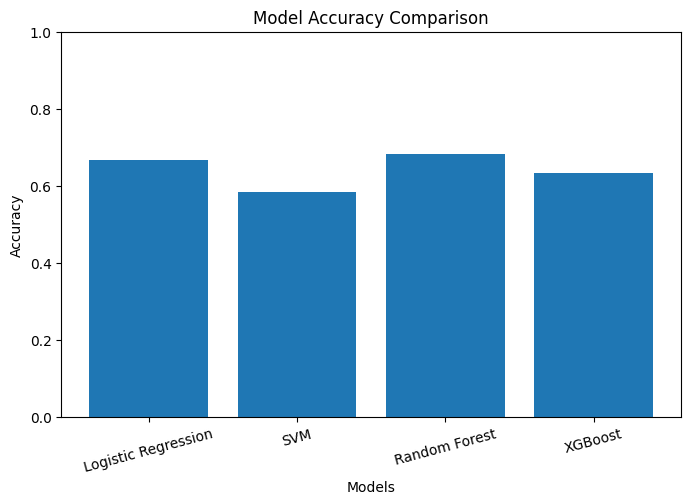

In [29]:
import matplotlib.pyplot as plt

model_names = [
    "Logistic Regression",
    "SVM",
    "Random Forest",
    "XGBoost"
]

accuracies = [
    lr_acc,
    svm_acc,
    rf_acc,
    xgb_acc
]

plt.figure(figsize=(8,5))
plt.bar(model_names, accuracies)
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

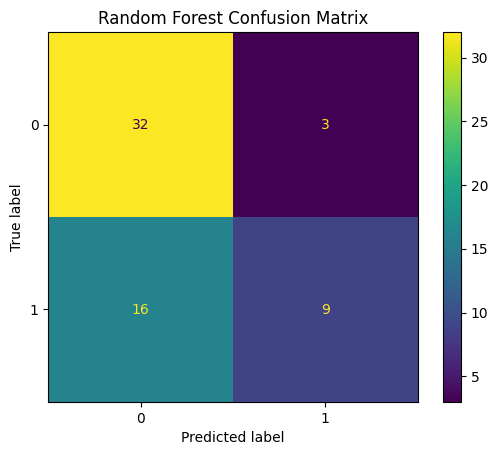

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [31]:
new_patient = [[
    55, 1, 2, 130, 250, 0, 1,
    150, 0, 1.0, 1, 0, 2
]]

prediction = rf_model.predict(new_patient)

if prediction[0] == 1:
    print("Prediction: Risk Detected")
else:
    print("Prediction: No Risk Detected")

Prediction: No Risk Detected


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
